In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.parent))
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List
import json

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
@dataclass
class BarPlotData:
    y: List[float]
    name: str

In [8]:
FILE_MAPPING = {
    "qwen3-30b-a3b-spec-bundle_results_20251217_083105.jsonl": "QiaolingChen/Sglang-eagle3-Qwen3-30B-A3B-Instruct-2507",
}
NO_EAGLE_BASELINE = "no-eagle.jsonl"

In [9]:
def read_jsonl(file_path: str) -> List[BarPlotData]:
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # the output format will be 
    # {
    #     <benchmark>: {
    #         <eagle3-config>: {
    #             "throughput": xxx,
    #             "acc_latency": xxx,
    #         }
    #     }
    # }

    output = {}
    for benchmark, benchmark_data in data.items():
        for data in benchmark_data:
            eagle3_config = f"{data['batch_size']}-{data['steps']}-{data['topk']}-{data['num_draft_tokens']}"
            throughput = data['metrics'][0]['output_throughput']
            acc_len = data['metrics'][0]['accept_length']

            if benchmark not in output:
                output[benchmark] = {}

            output[benchmark][eagle3_config] = {
                "throughput": throughput,
                "acc_len": acc_len,
            }

    return output

def get_data_bars() -> List[BarPlotData]:
    baseline_data = read_jsonl(NO_EAGLE_BASELINE)

    data = {}
    for file_name, hf_repo in FILE_MAPPING.items():
        exp_data = read_jsonl(file_name)
        data[hf_repo] = exp_data

    # get the different types of configs
    available_configs = []
    available_benchmarks = []
    for hf_repo, exp_data in data.items():
        for benchmark, benchmark_data in exp_data.items():
            available_configs.extend(list(benchmark_data.keys()))
            available_benchmarks.append(benchmark)
    # print(available_configs)
    available_configs = list(set(available_configs))
    available_benchmarks = list(set(available_benchmarks))

    # get the baselien values
    baseline_throughput_vals = []
    baseline_acc_len_vals = []
    for benchmark in available_benchmarks:
        vals = list(baseline_data[benchmark].values())[0]
        baseline_throughput_vals.append(vals['throughput'])
        baseline_acc_len_vals.append(vals['acc_len'])

    for config in available_configs:
        if config.endswith("0-0-0"):
            continue
        throughput_bars = []
        acc_len_bars = []
        throughput_bars.append(BarPlotData(y=baseline_throughput_vals, name="No Eagle"))
        acc_len_bars.append(BarPlotData(y=baseline_acc_len_vals, name="No Eagle"))

        for hf_repo, exp_data in data.items():
            throughput_vals = []
            acc_len_vals = []
            for benchmark in available_benchmarks:
                throughput = exp_data[benchmark][config]['throughput']
                acc_len = exp_data[benchmark][config]['acc_len']
                throughput_vals.append(throughput)
                acc_len_vals.append(acc_len)

            throughput_bar = BarPlotData(y=throughput_vals, name=hf_repo)
            acc_len_bar = BarPlotData(y=acc_len_vals, name=hf_repo)
            throughput_bars.append(throughput_bar)
            acc_len_bars.append(acc_len_bar)
        yield throughput_bars, acc_len_bars, available_benchmarks, config


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

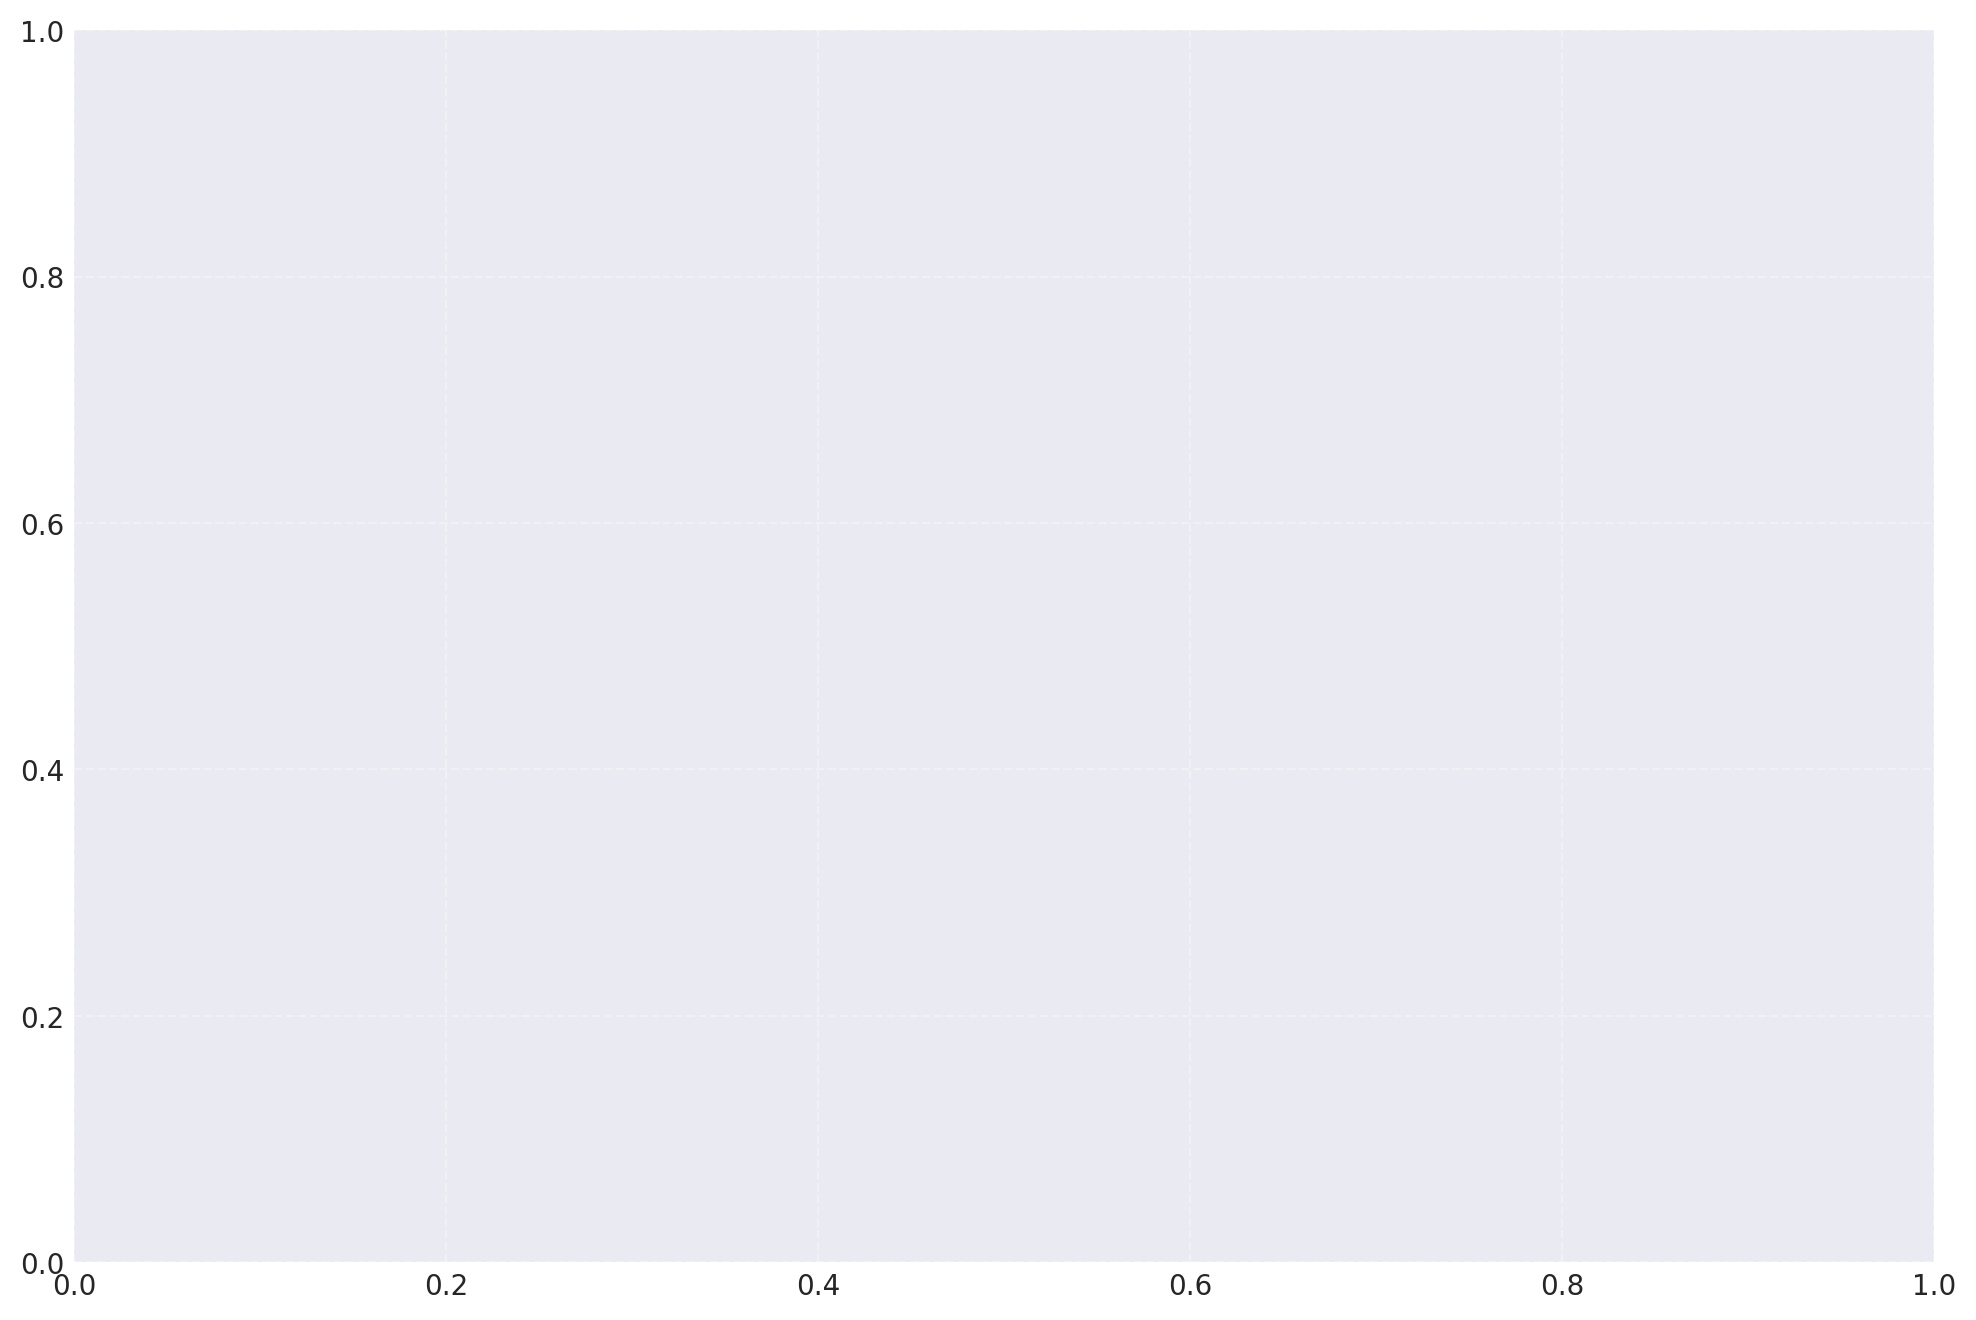

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

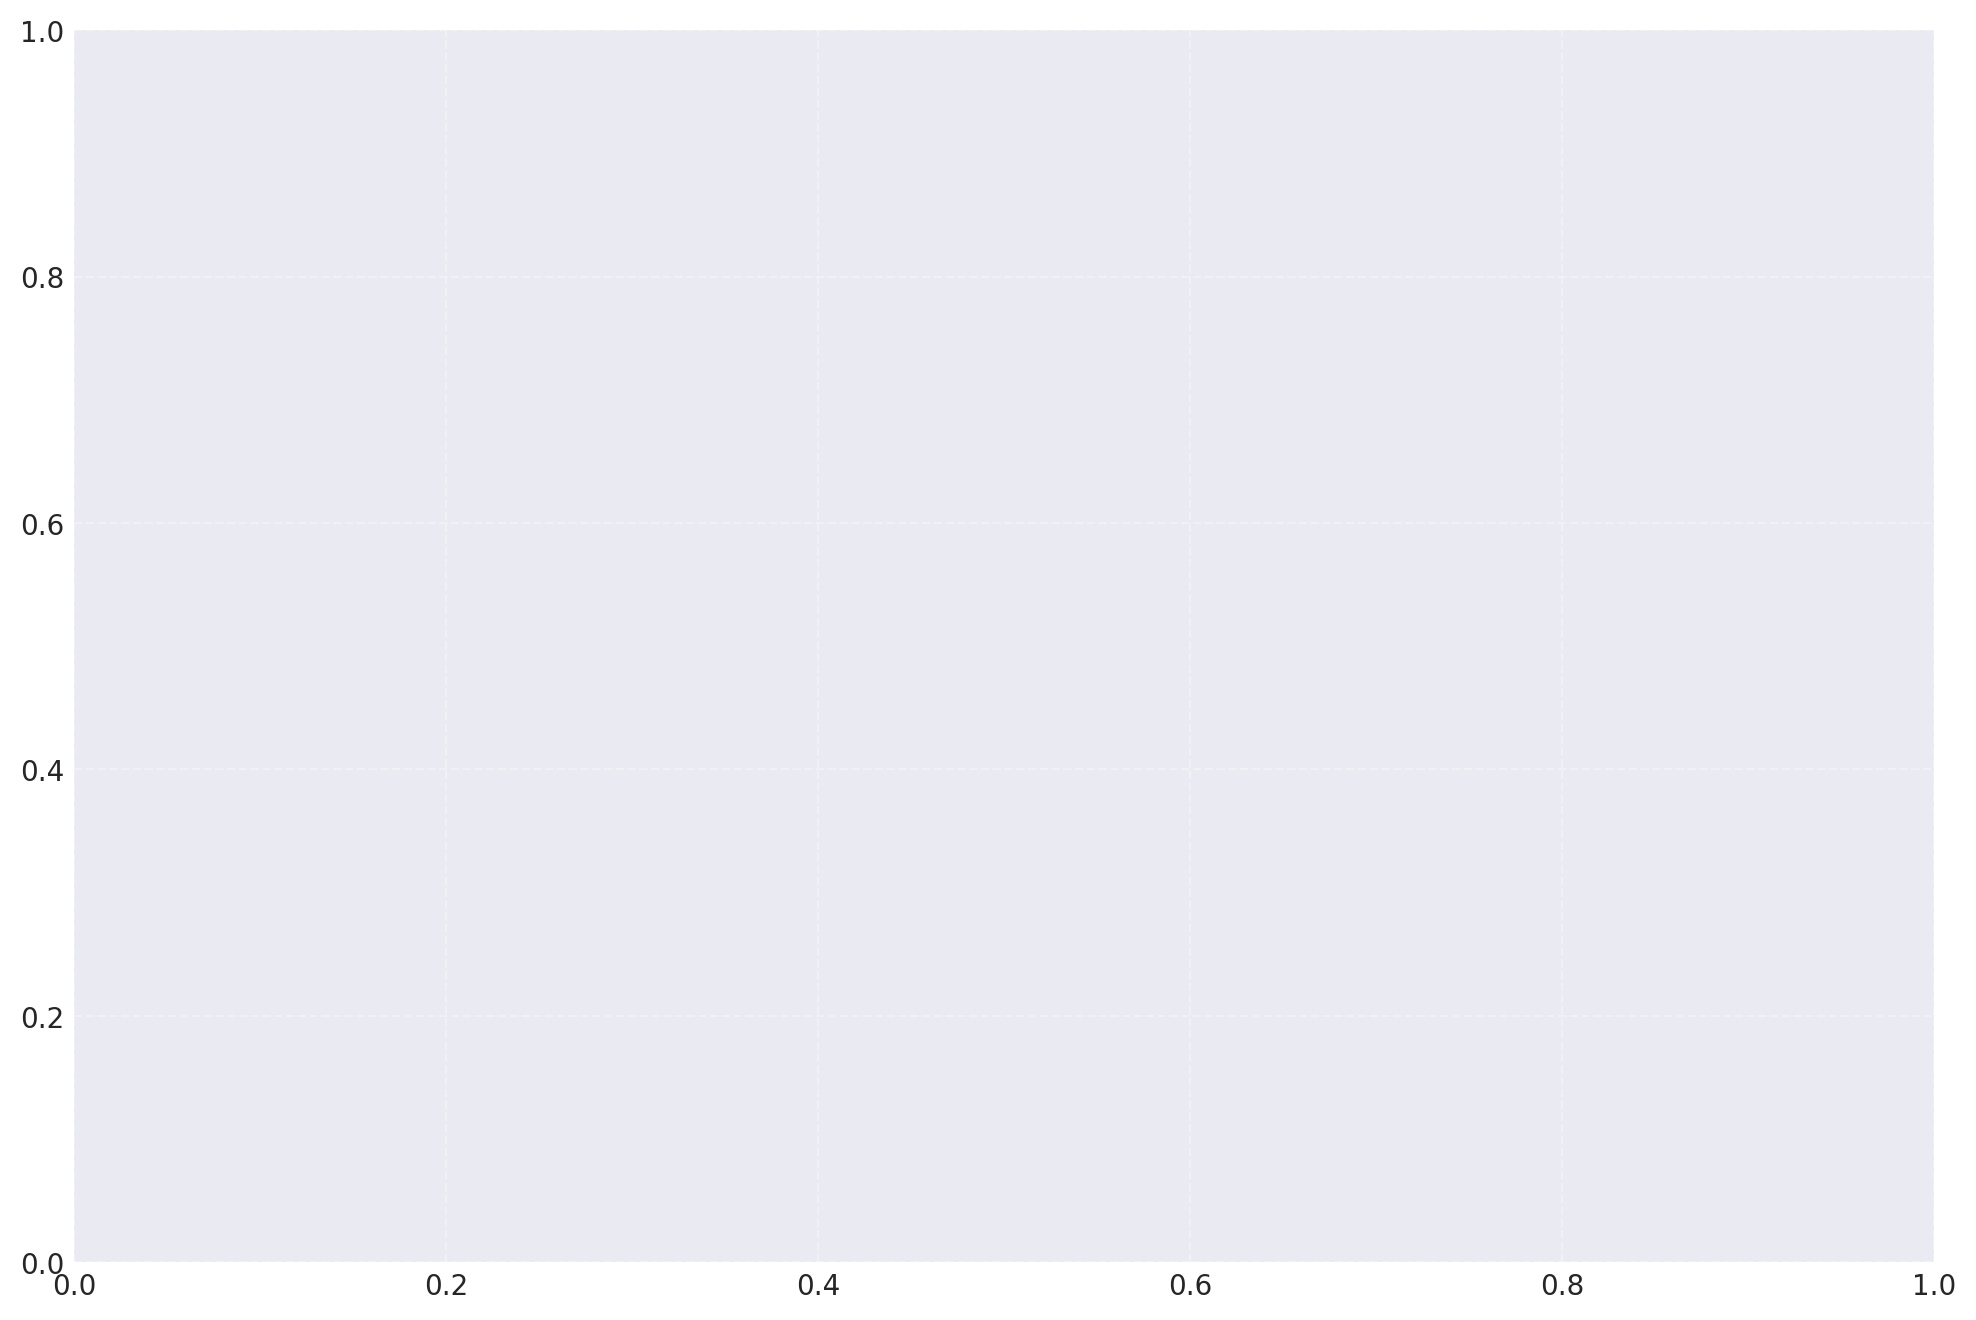

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

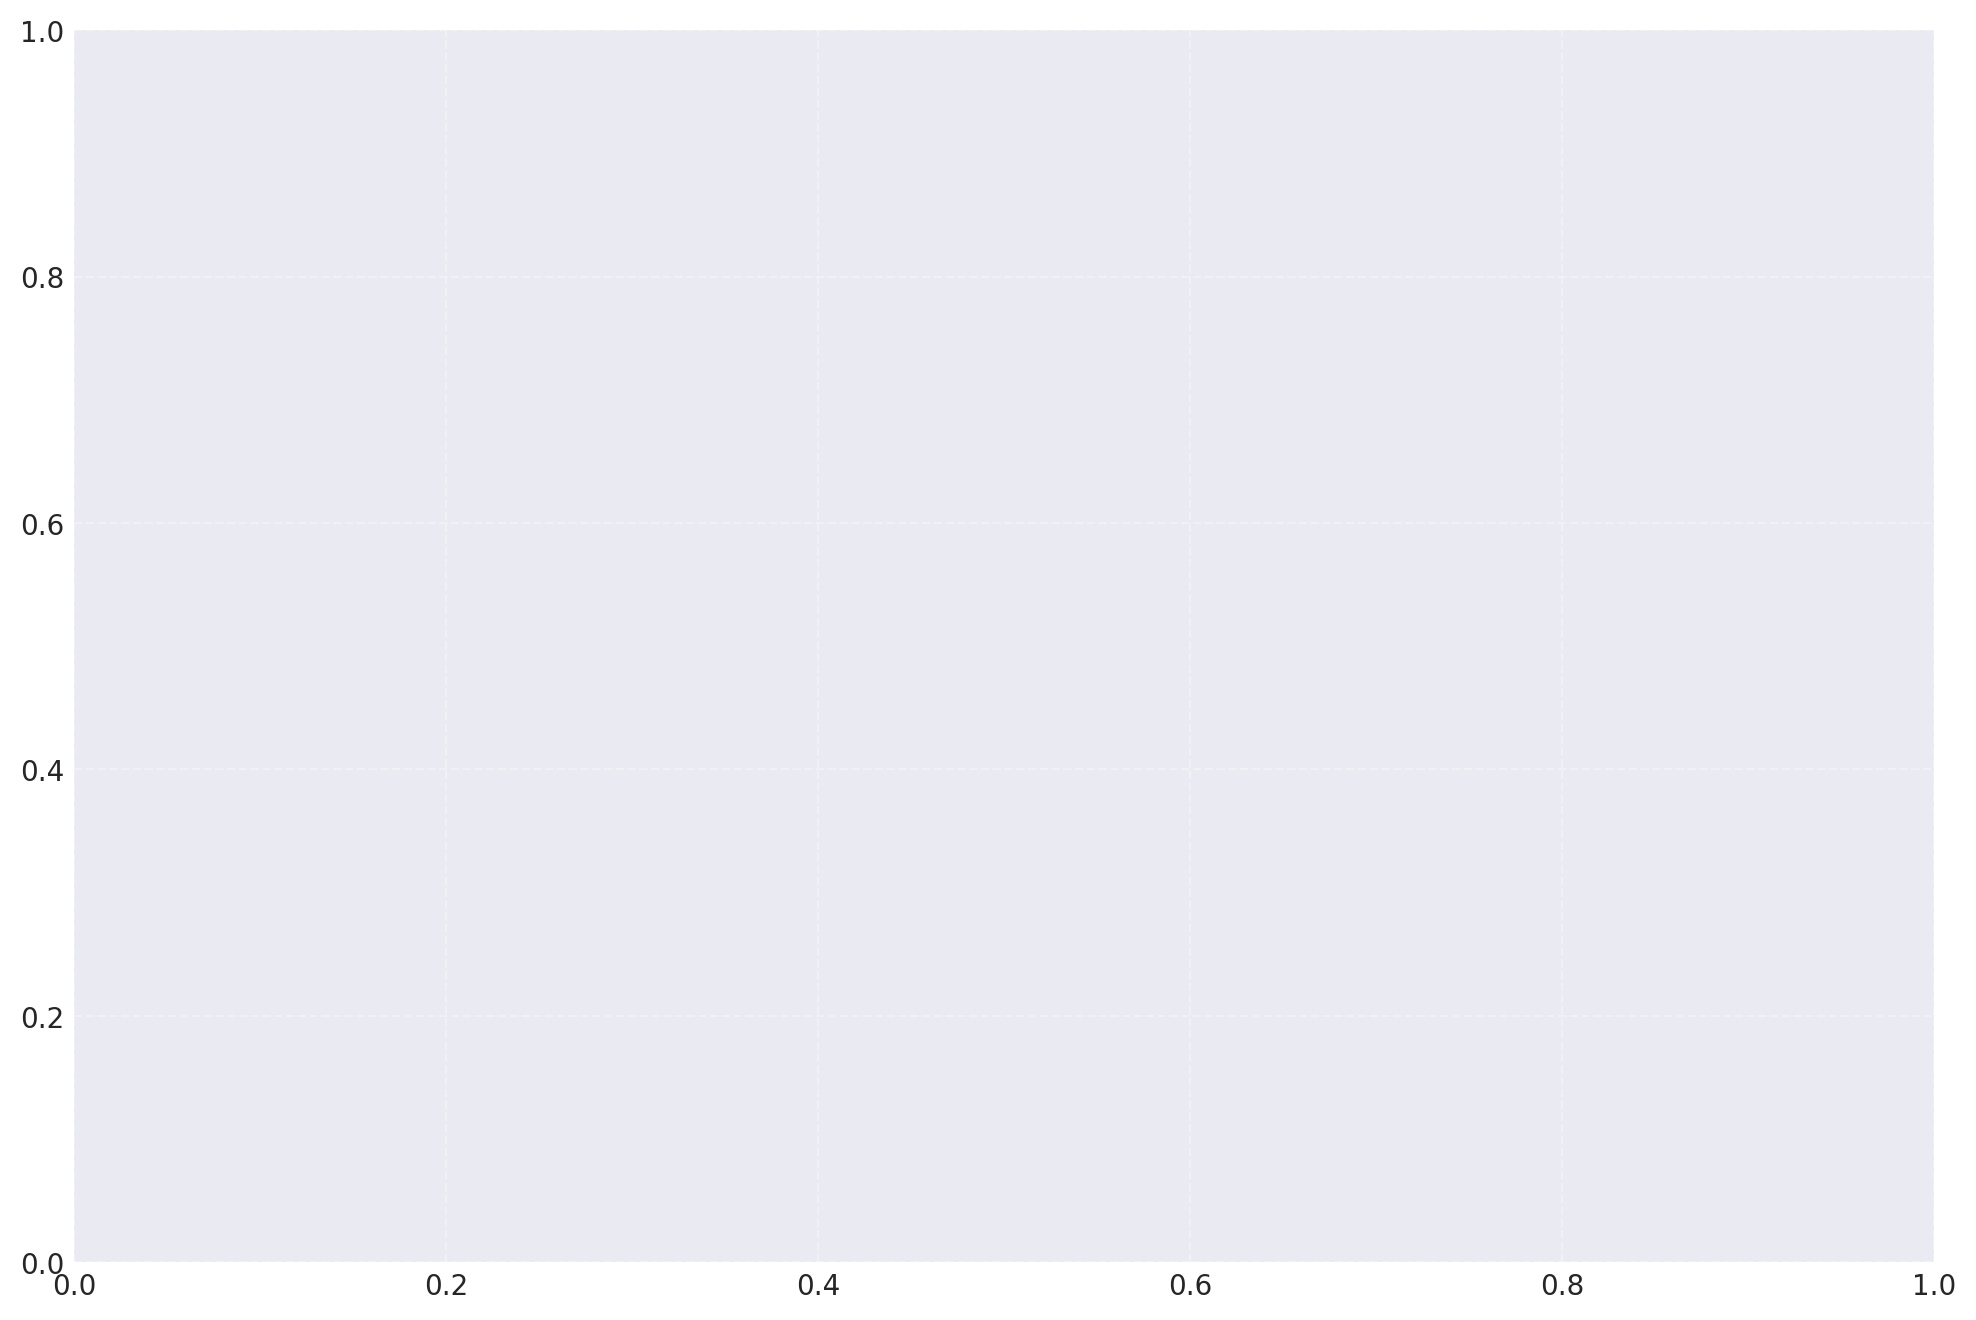

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

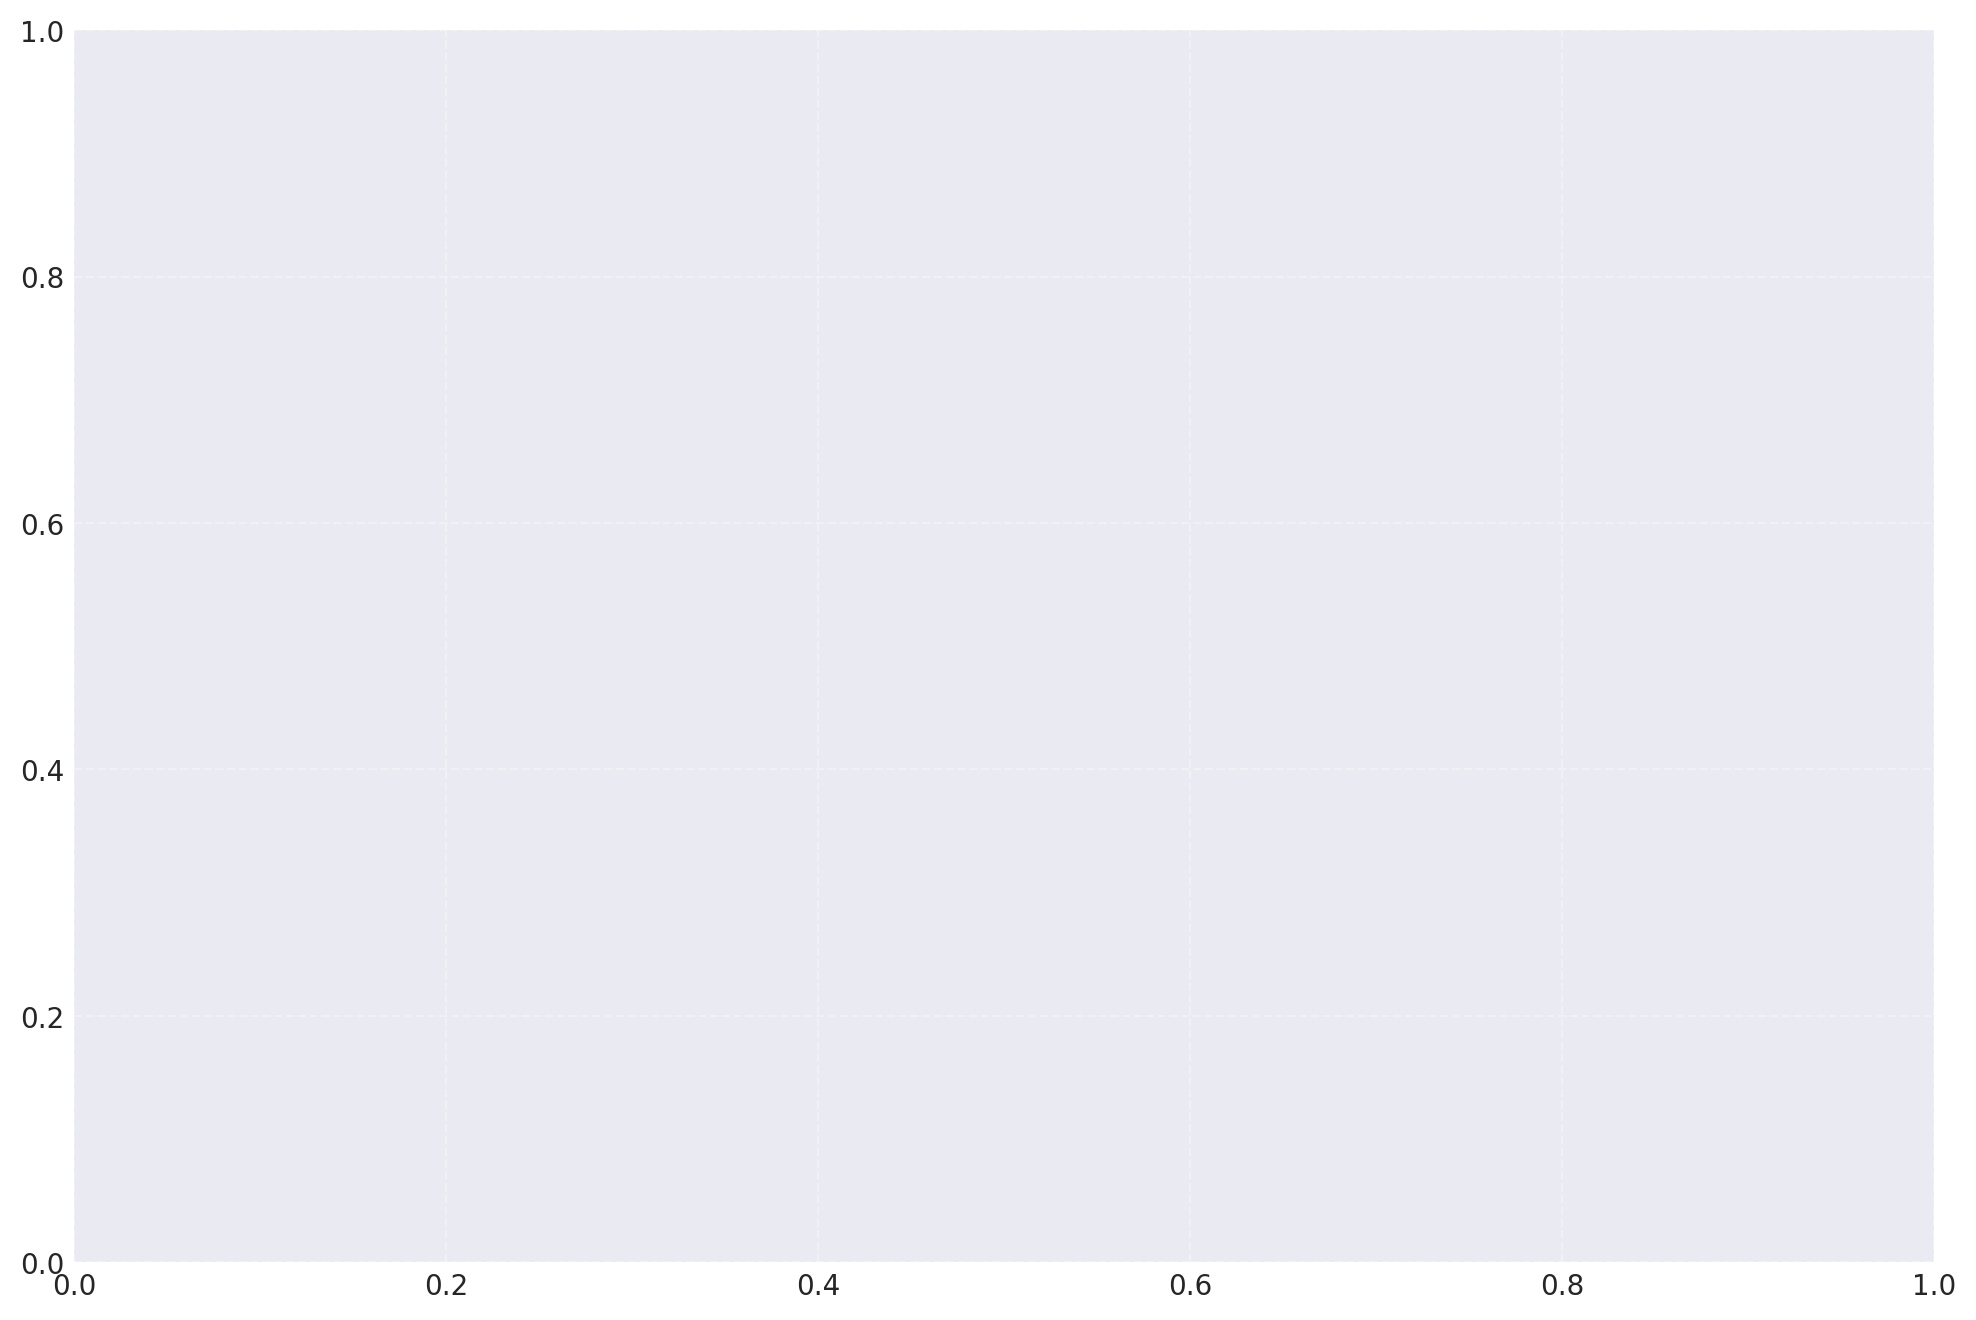

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

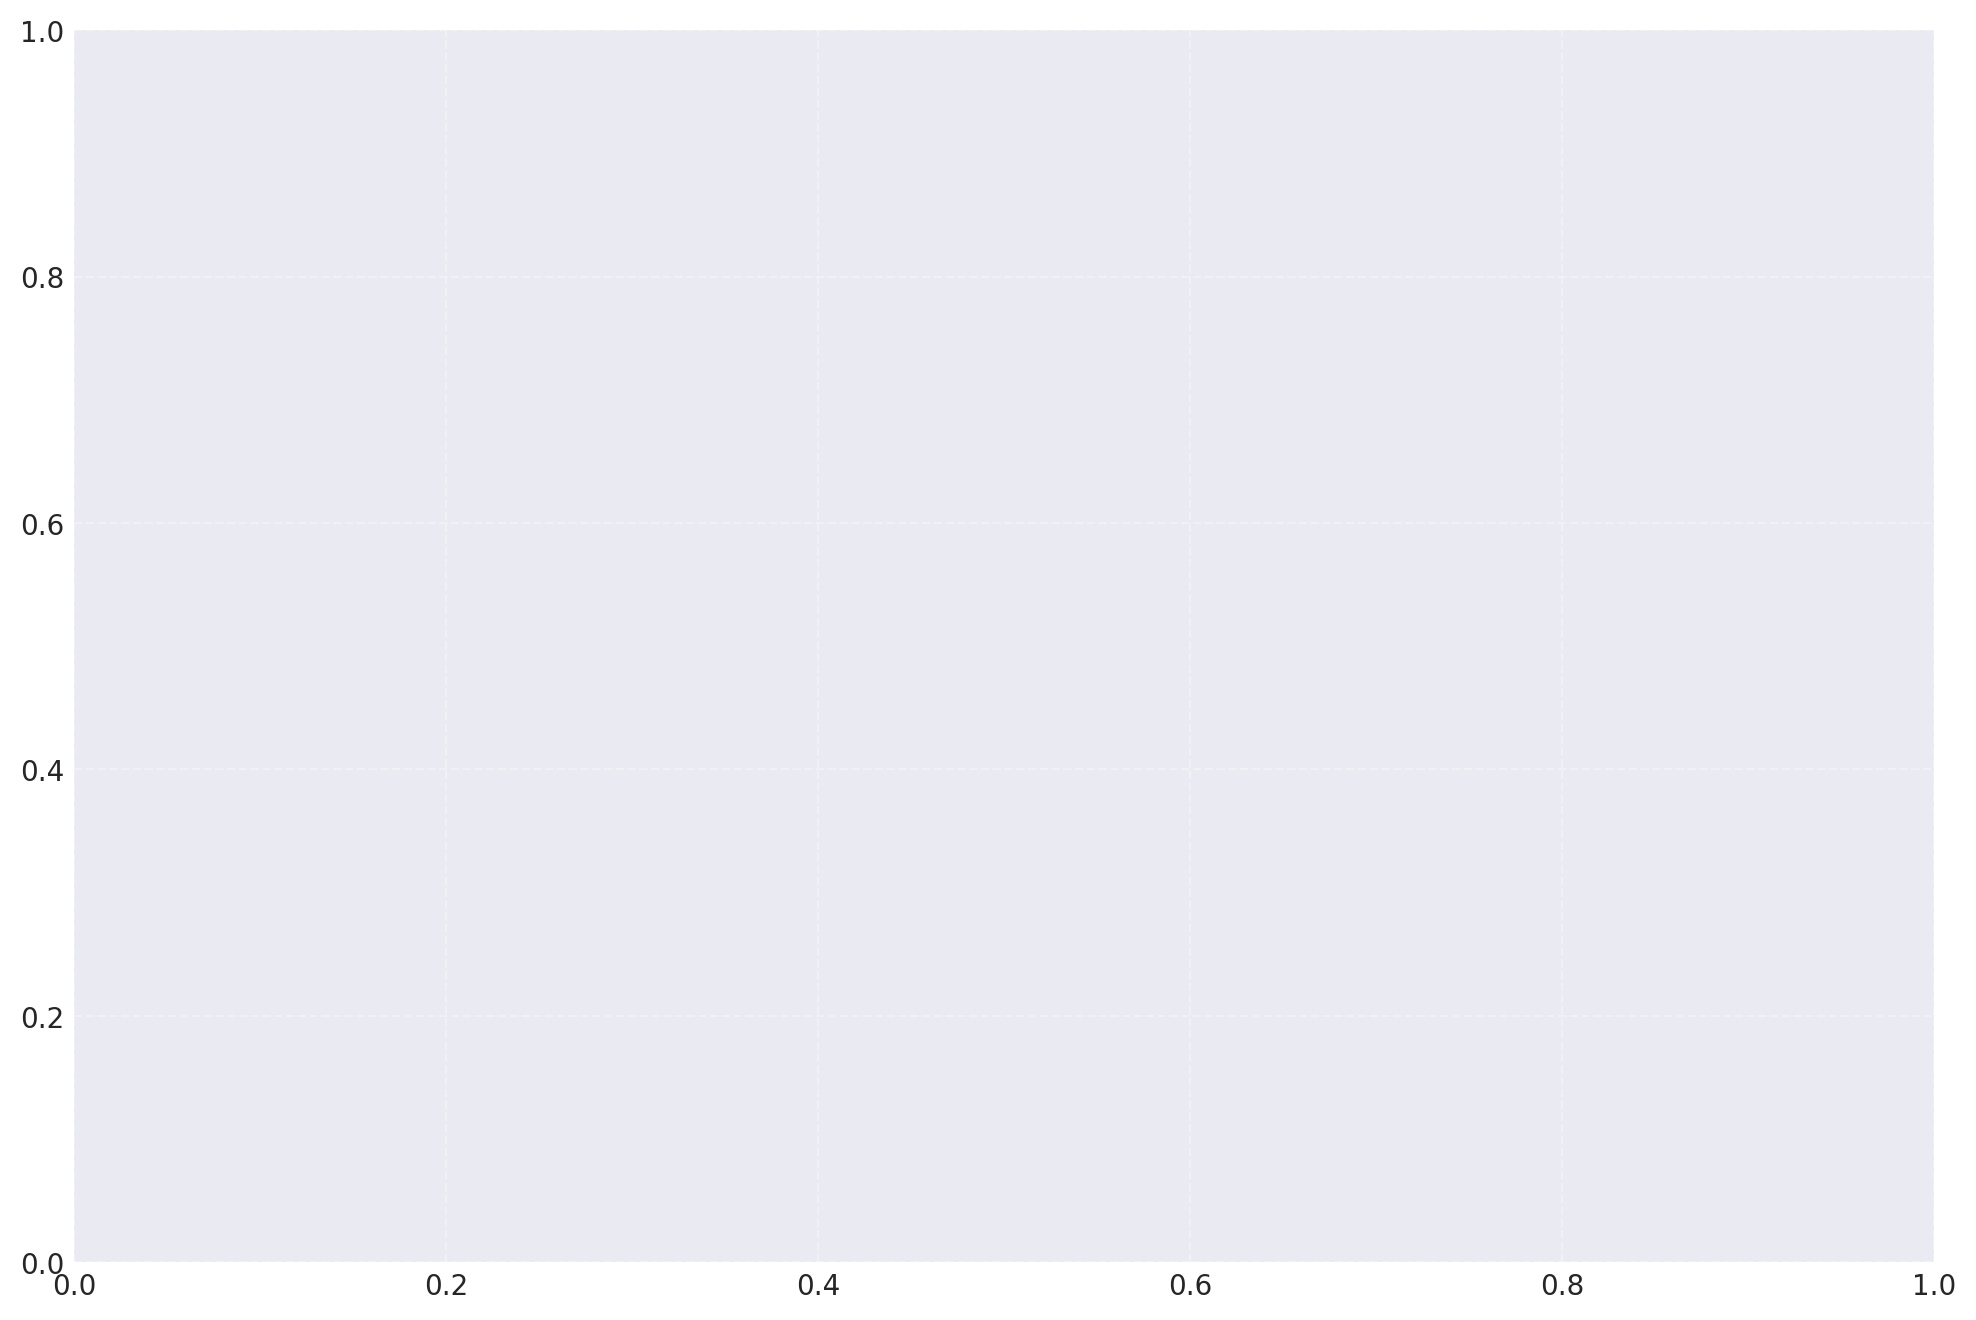

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

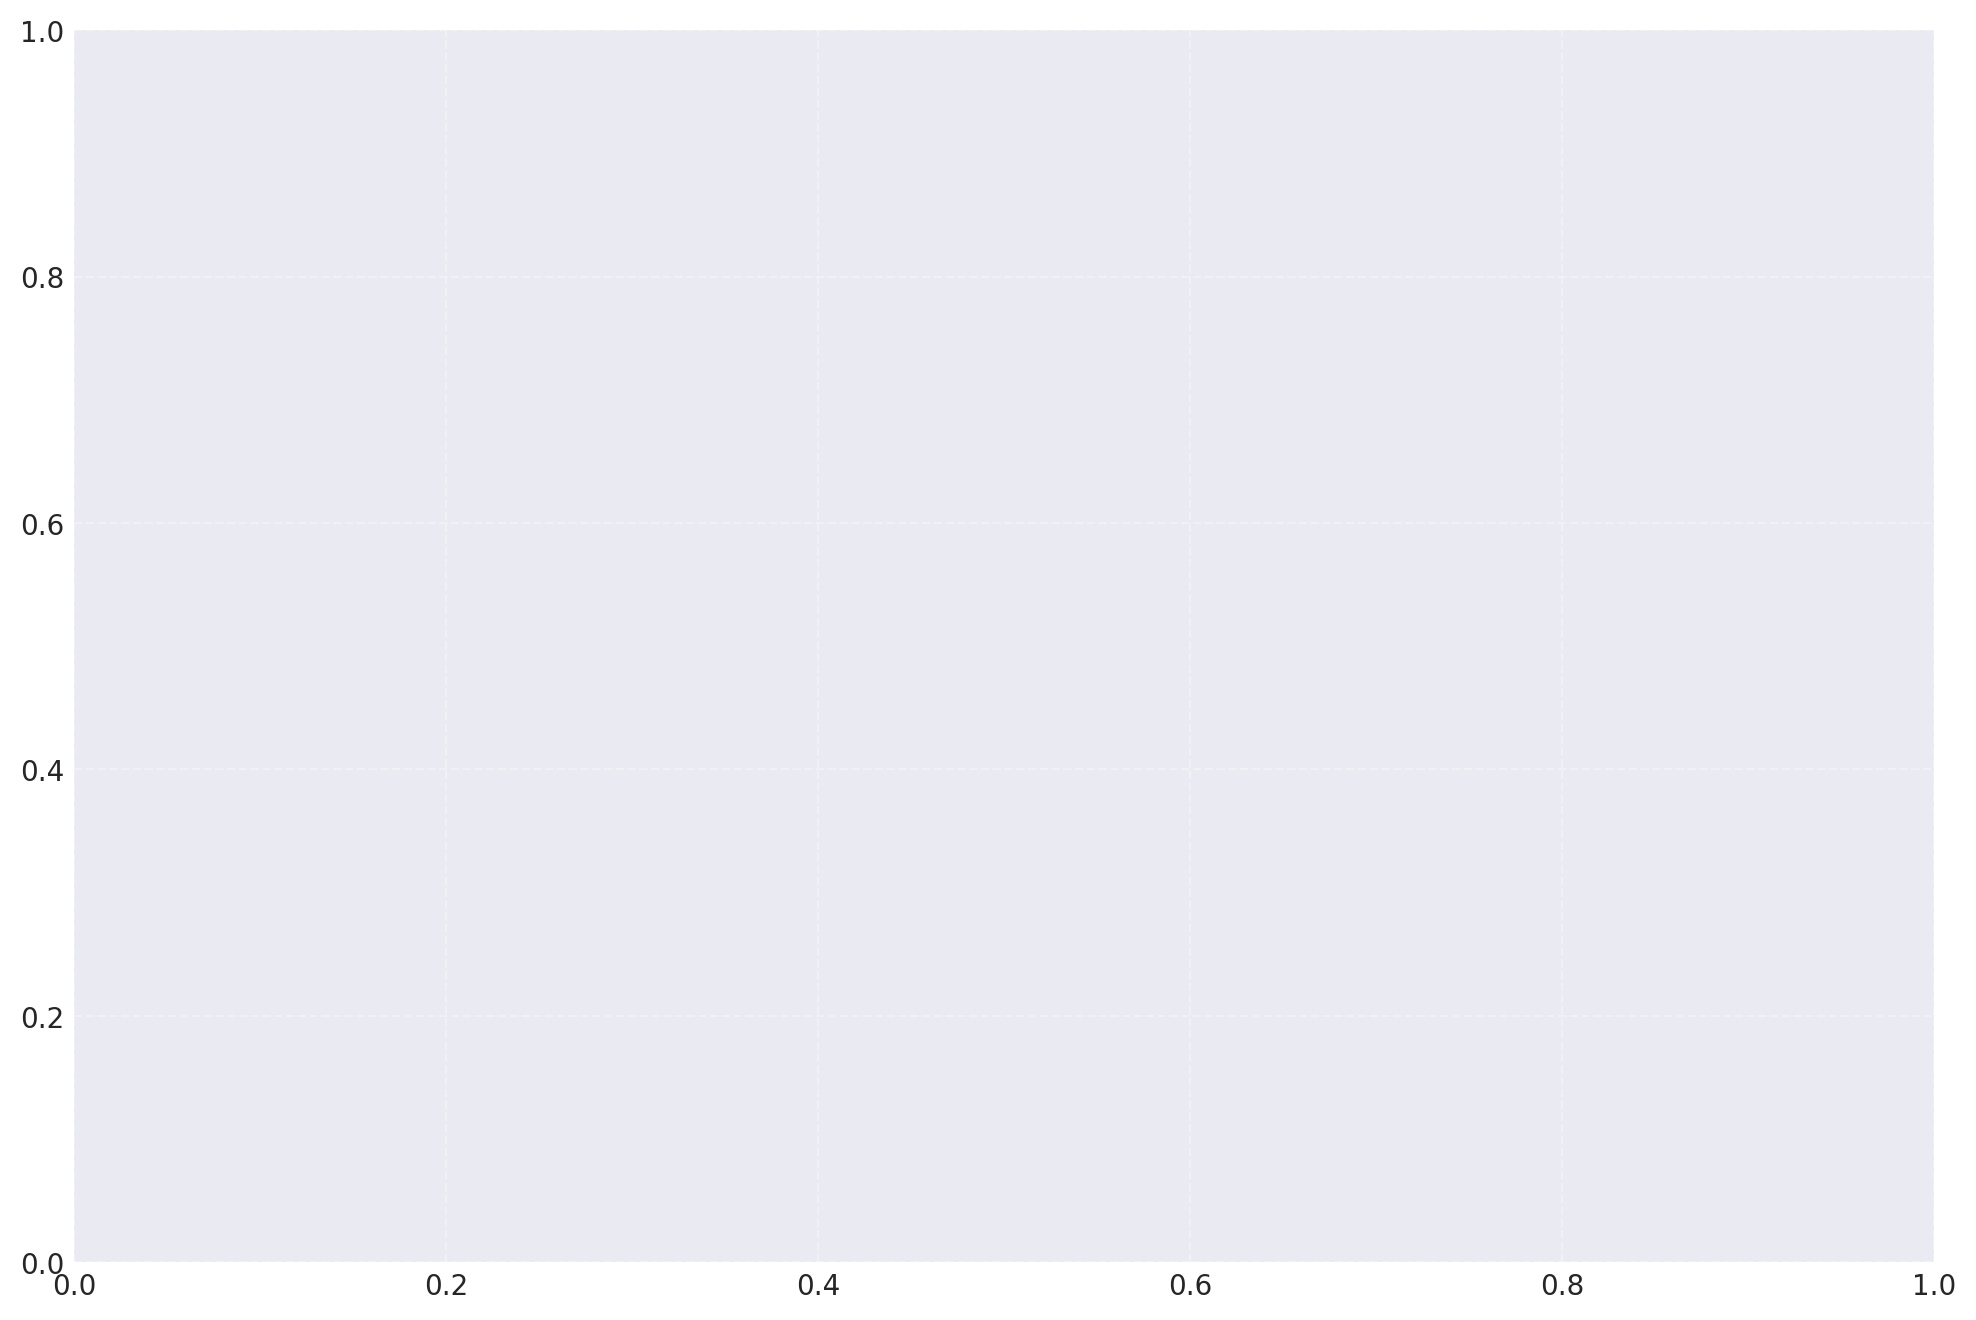

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

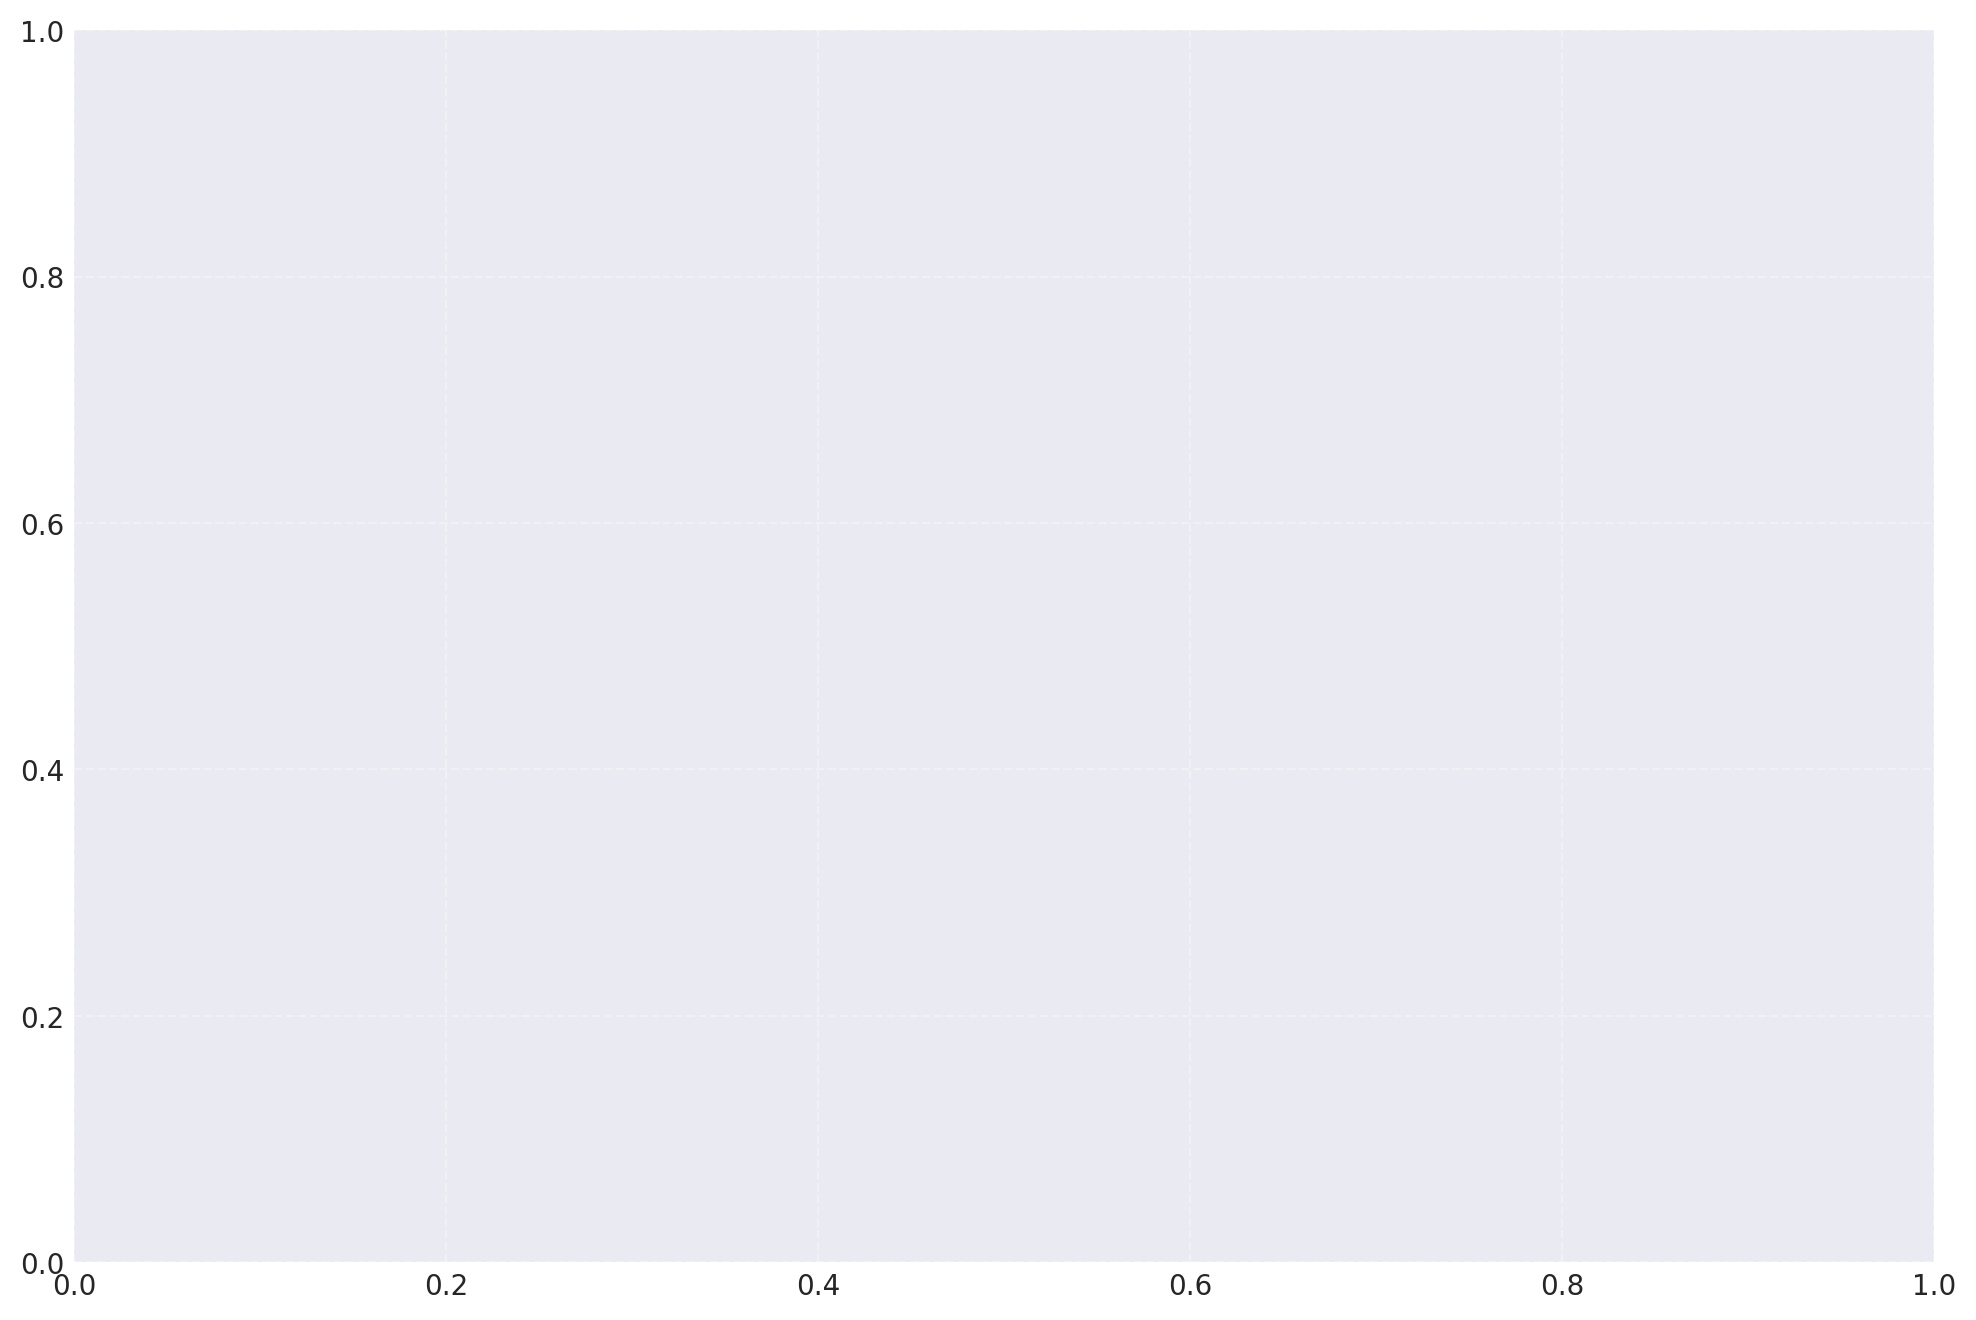

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

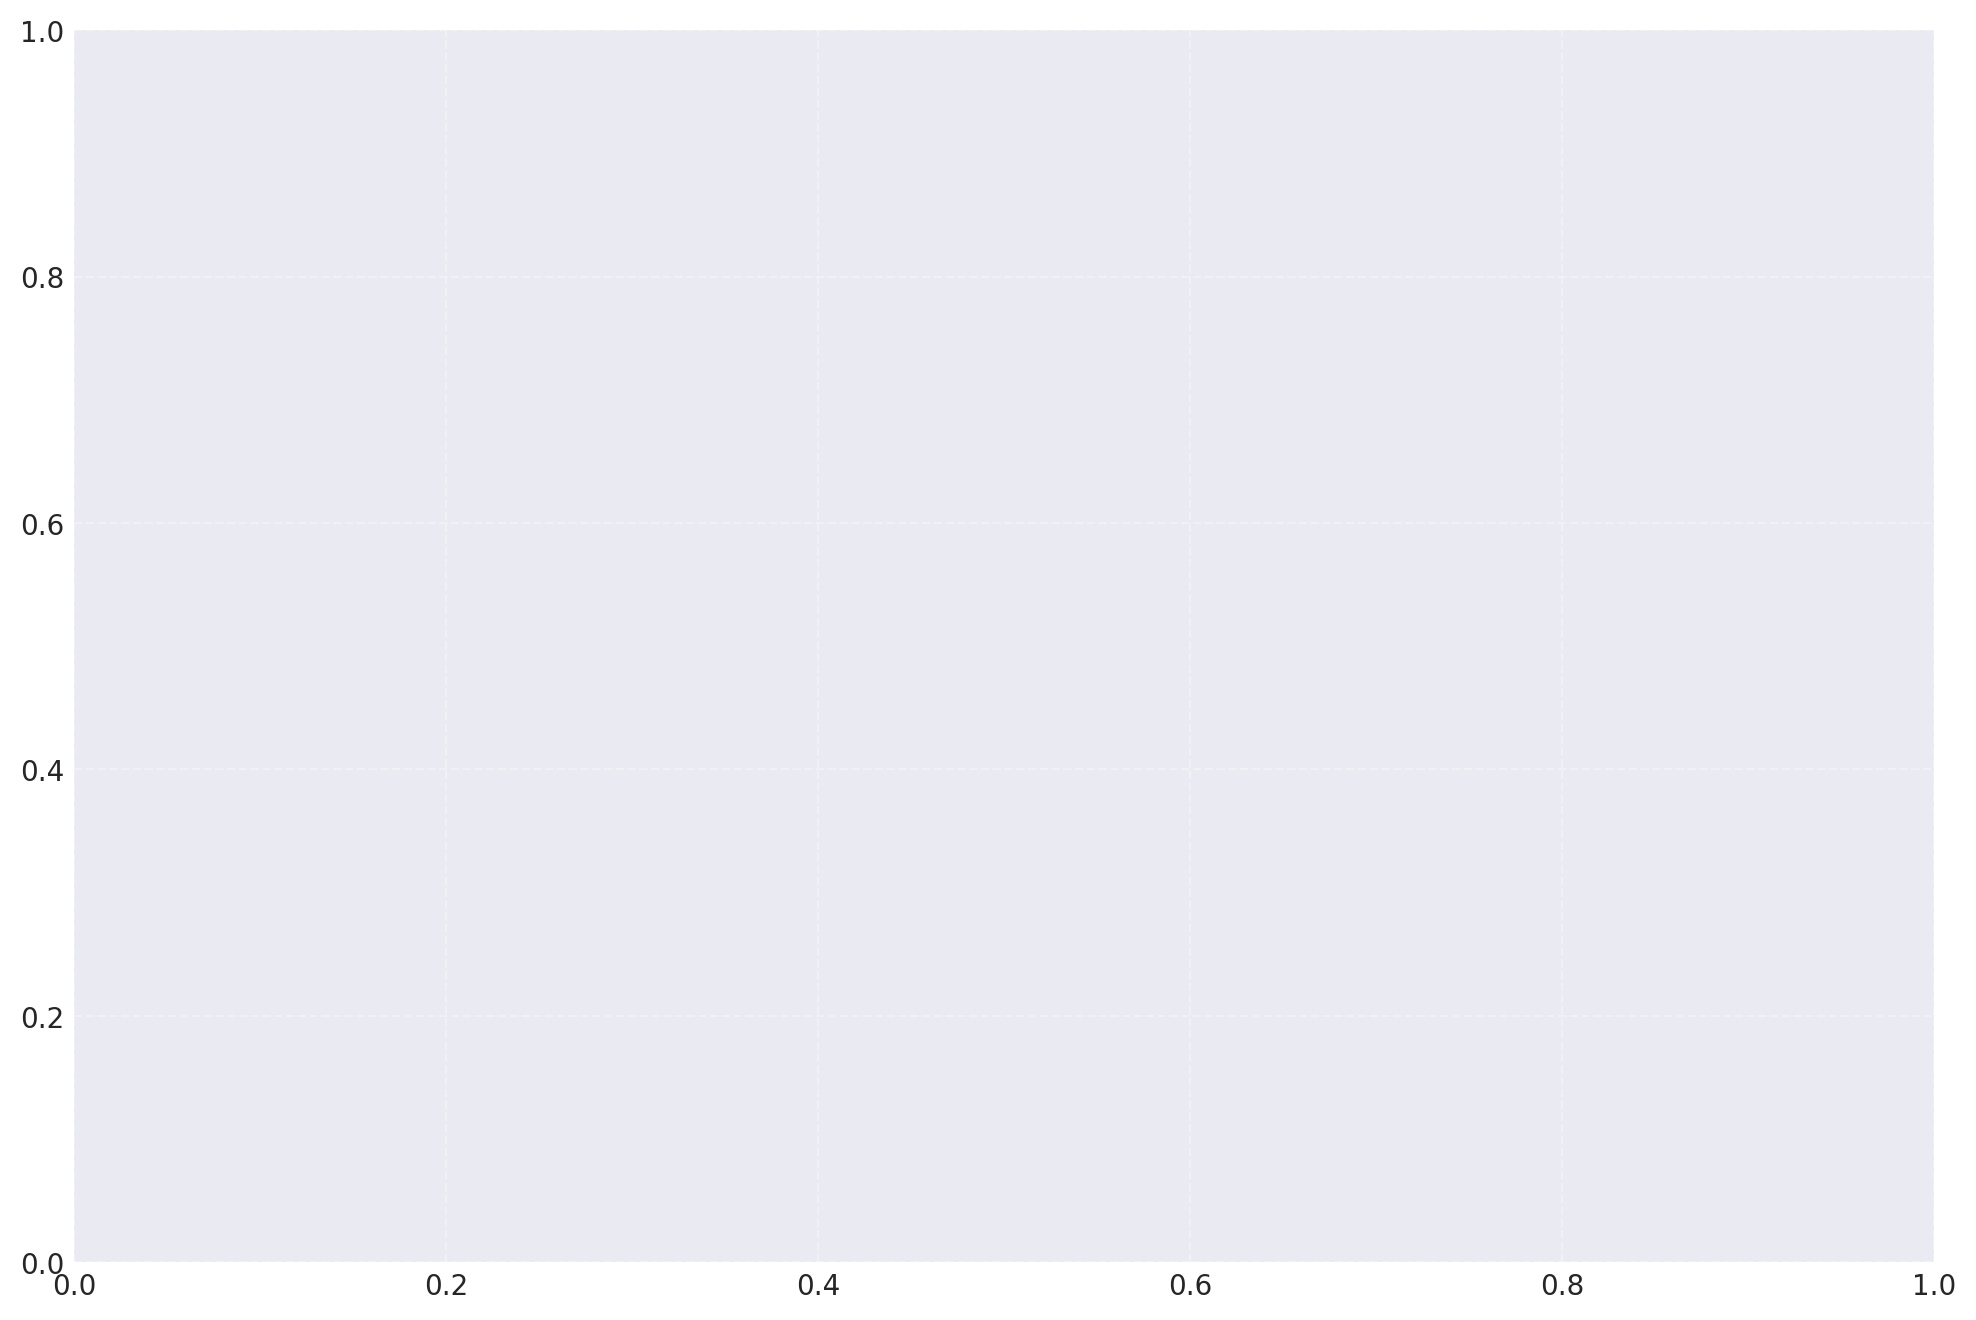

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

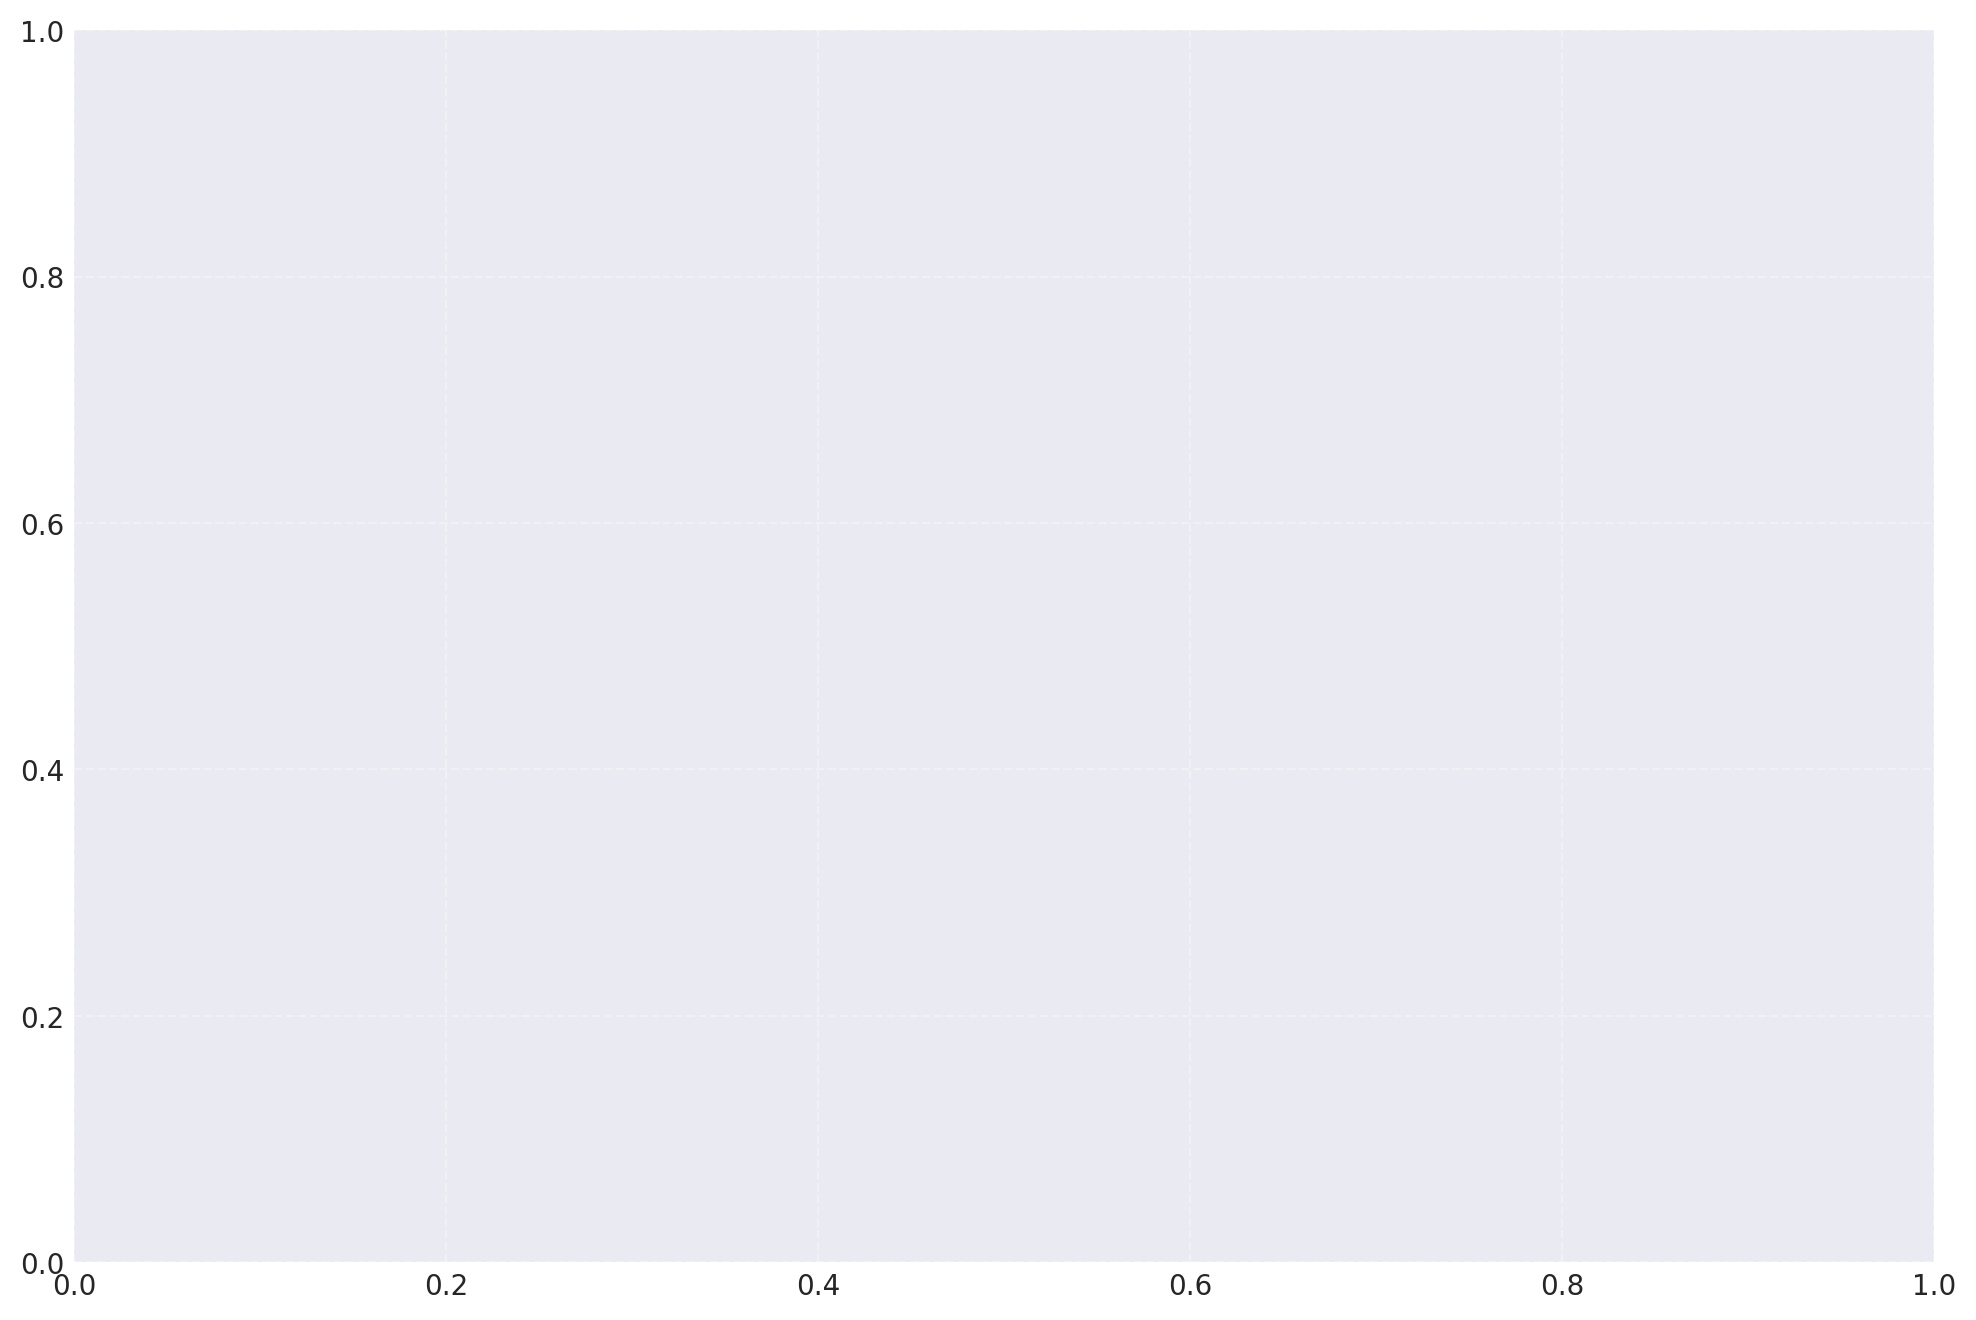

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

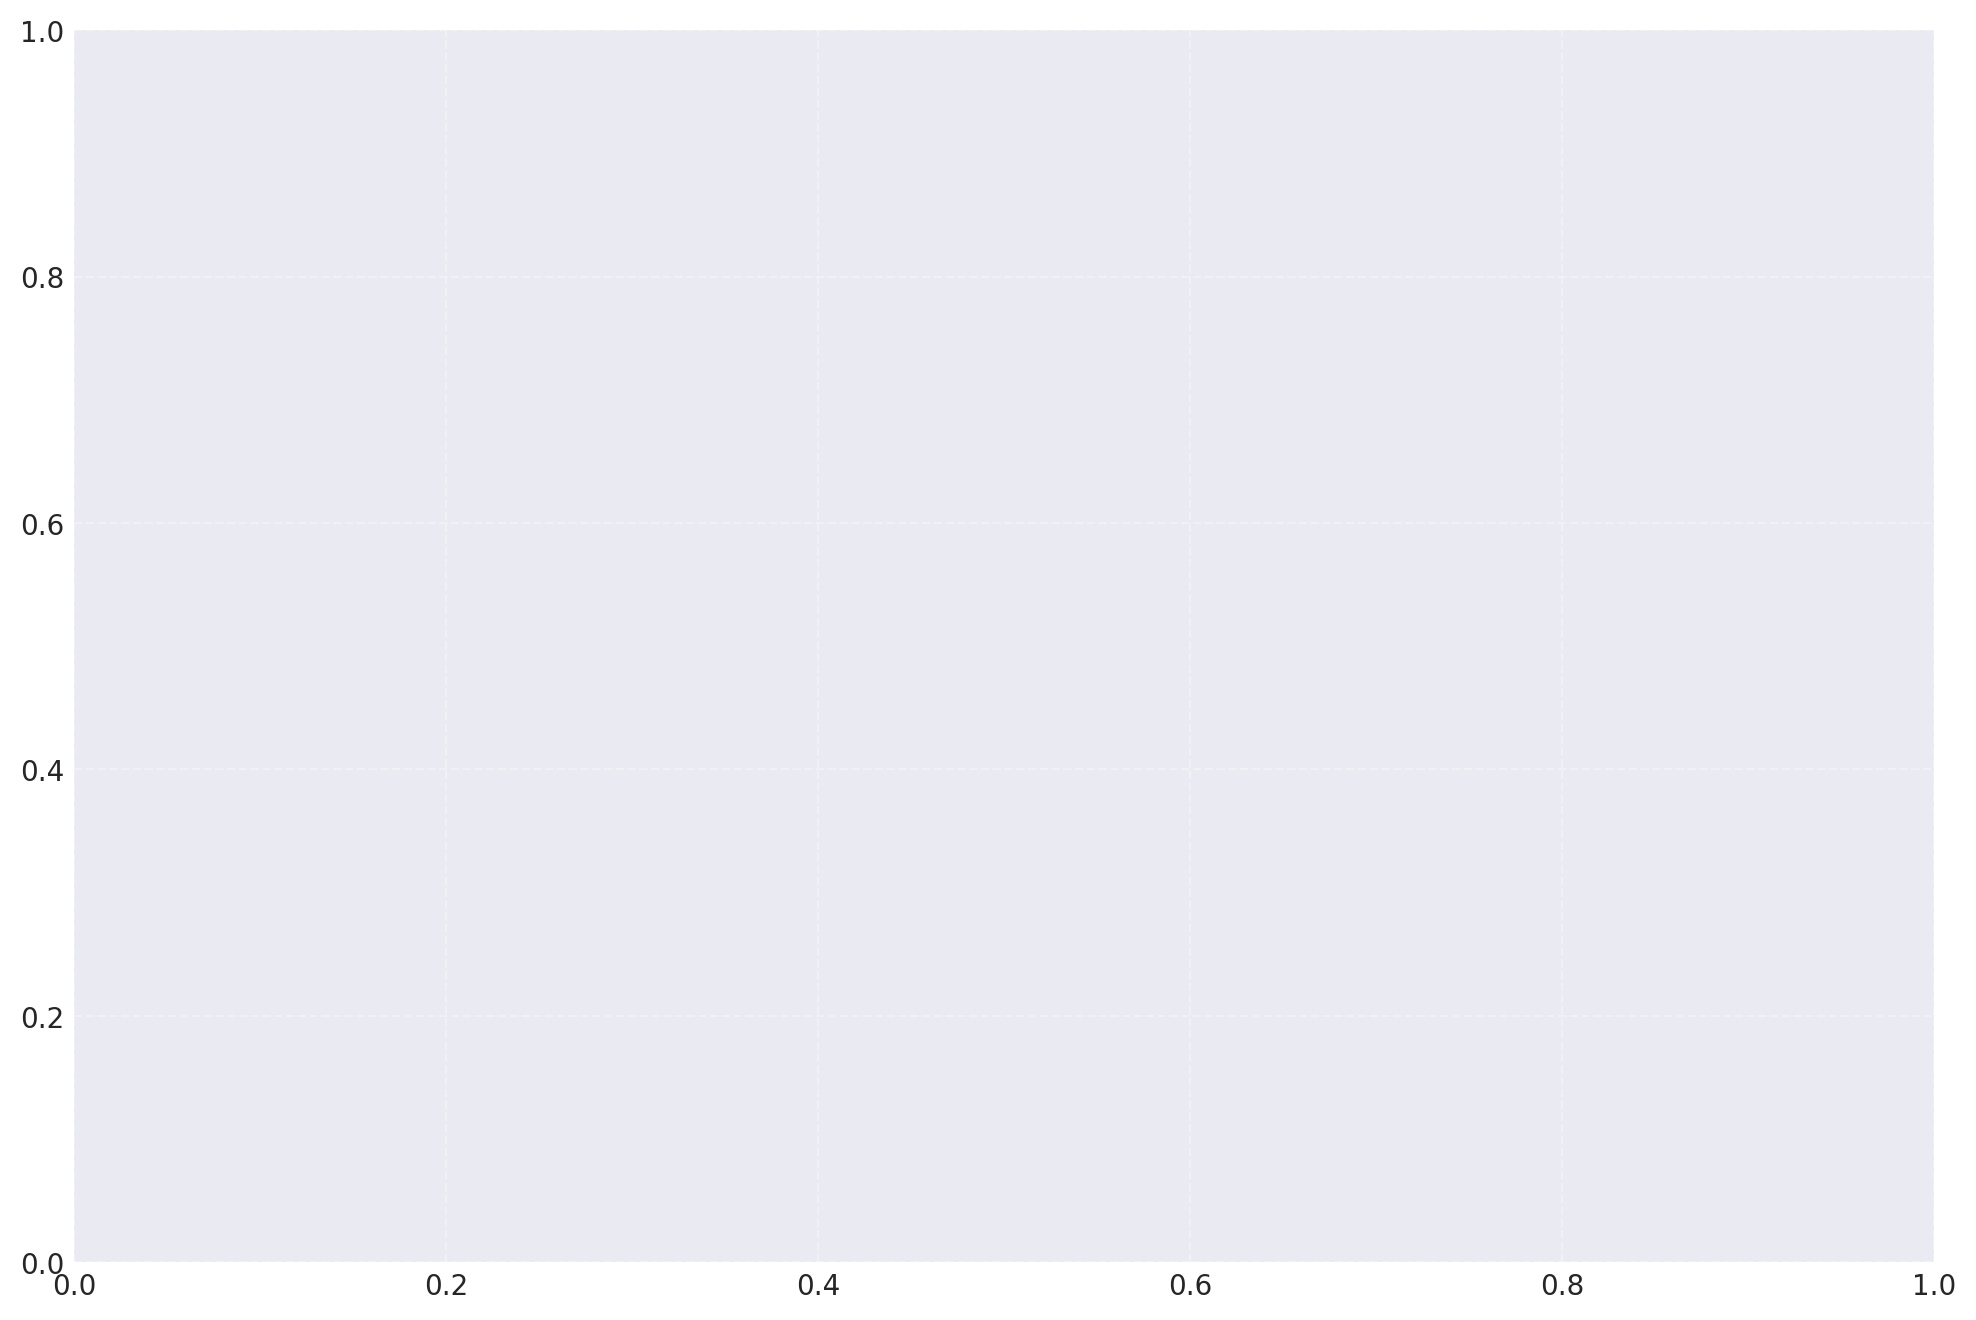

In [10]:
def generate_bar_plot(data_list: List[BarPlotData], x_label: str, y_label: str, title: str, x_ticks: List[str], show_legend: bool = True, show_grid: bool = True, num_legend_cols: int = 2):
    plt.figure(figsize=(12, 8))

    # compute the x point of each bar
    num_bars = len(data_list[0].y)
    num_data = len(data_list)
    bar_margin = 24
    bar_width = 6
    x = np.arange(num_bars) * bar_margin
    for idx, data in enumerate(data_list):
        cur_x = x + (idx - num_data / 2) * bar_width + bar_width / 2
        plt.bar(
            x=cur_x, 
            height=data.y, 
            color=common.COLORS[idx], 
            edgecolor='white', 
            linewidth=0.5, 
            alpha=0.9, 
            width=bar_width,
            label=data.name
            )

        # show values above the bar
        for i, y in enumerate(data.y):
            plt.text(
                x=cur_x[i], 
                y=y, 
                s=f"{y:.1f}", 
                ha='center', 
                va='bottom')

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)

    if x_ticks:
        plt.xticks(x, x_ticks, fontsize=common.X_TICK_FONT_SIZE)
        plt.yticks(fontsize=common.Y_TICK_FONT_SIZE)
    
    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, fontsize=common.LEGEND_FONT_SIZE, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=num_legend_cols)

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    # plt.tight_layout()


# Generate sample data
for throughput_bars, acc_len_bars, available_benchmarks, config in get_data_bars():
    bs, steps, topk, num_draft_tokens = config.split('-')

    if steps == 0 and topk == 0 and num_draft_tokens == 0:
        continue

    generate_bar_plot(
            data_list=throughput_bars,
            x_label='Benchmarks',
            y_label='Throughput (tokens/s)',
            title=f'Inference Throughput (bs={bs}, steps={steps}, topk={topk}, num_draft_tokens={num_draft_tokens})',
            x_ticks=available_benchmarks,
            show_legend=True,
            show_grid=True,
            num_legend_cols=1
            )
    # plt.show()
    plt.savefig(f'plots/{config}-throughput.png', dpi=300, bbox_inches="tight")
    plt.cla()


    generate_bar_plot(
            data_list=acc_len_bars,
            x_label='Benchmarks',
            y_label='Accept Length',
            title=f'Accept Length (bs={bs}, steps={steps}, topk={topk}, num_draft_tokens={num_draft_tokens})',
            x_ticks=available_benchmarks,
            show_legend=True,
            show_grid=True,
            num_legend_cols=1
            )
    plt.savefig(f'plots/{config}-acc-len.png', dpi=300, bbox_inches="tight")
    plt.cla()